In [196]:
import keras.models as models
import pandas as pd
ds=pd.read_csv('plant_health_data.csv')
ds["Plant_Health_Status"]=ds["Plant_Health_Status"].map({"High Stress":0,"Moderate Stress":1,"Healthy":2})
ds.shape

(1200, 14)

In [197]:
ds.head()


,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,0
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,0
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,0
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,0
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,0


In [198]:
ds.iloc[:, 13].unique()


array([0, 1, 2])

In [199]:
 ds=ds.values

In [200]:
data=ds[:,2:13]
target=ds[:,13]

In [201]:
print(data)

[[27.521108772254976 22.24024536256306 21.90043535506952 ...
  39.0761990273964 35.703005710811865 0.9414021464707312]
 [14.835566151888916 21.706763280909925 18.68089193676625 ...
  17.944826069293086 27.993295774186056 0.1648993610796132]
 [17.086361974997438 21.180945559285547 15.392939129667838 ...
  35.70653021497076 43.64630751994847 1.0817280414192725]
 ...
 [23.49572280400097 21.680239711730323 15.499764492331863 ...
  28.473232564415976 38.324484260580135 0.8800185060271297]
 [30.97167528596308 23.01948793340109 21.934917595992225 ...
  19.750041860944695 46.02752857086873 0.3445974177261821]
 [24.406356509242958 25.72460506249186 23.358572603199384 ...
  10.48606197527416 41.97709830715635 0.0475405740673147]]


In [202]:
from tensorflow.keras.utils import to_categorical
new_target=to_categorical(target)
print(new_target)


[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [203]:
import matplotlib.pyplot as plt

In [204]:
# for i in range(ds.shape[1]):
#     plt.hist(ds[:,i])
#     plt.xlabel('Values')
#     plt.ylabel('Frequency')
#     plt.title('Histogram')
#     plt.show()



In [205]:

from sklearn.preprocessing import MinMaxScaler
scaler_data= MinMaxScaler()
scaler_data.fit(data)
data_scaled=scaler_data.transform(data)

In [206]:
# for i in range(data_scaled.shape[1]):
#     plt.hist(data_scaled[:, i], bins=15)
#     plt.title(f'Feature {i}')
#     plt.show()


In [207]:
model =models.Sequential()

In [208]:
import keras.models as models
import keras.layers as layers
from keras.layers import Dropout
import numpy as np

In [209]:
from tensorflow.keras import Sequential, layers

model = Sequential()

# Input + first hidden layer
model.add(layers.Input(shape=(11,)))   # 11 features
model.add(layers.Dense(64, activation='relu'))
model.add(Dropout(0.7))
# Hidden layers
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(Dropout(0.7))
# Output layer
model.add(layers.Dense(3, activation='sigmoid'))
model.summary()



Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                     │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_60 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_61 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,427 (13.39 KB)

 Trainable params: 3,427 (13.39 KB)

 Non-trainable params: 0 (0.00 B)

In [210]:
model.compile(optimizer ='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [211]:
from sklearn.model_selection import train_test_split
train_data,test_data,train_target,test_target=train_test_split(data_scaled,new_target,test_size=0.2)
history=model.fit(train_data,train_target,epochs=1000,validation_data=(test_data,test_target))

Epoch 1/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3438 - loss: 1.1926 - val_accuracy: 0.3708 - val_loss: 1.0807
Epoch 2/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3927 - loss: 1.1093 - val_accuracy: 0.3875 - val_loss: 1.0806
Epoch 3/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3906 - loss: 1.0949 - val_accuracy: 0.3917 - val_loss: 1.0793
Epoch 4/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4031 - loss: 1.0851 - val_accuracy: 0.3917 - val_loss: 1.0763
Epoch 5/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4302 - loss: 1.0804 - val_accuracy: 0.3917 - val_loss: 1.0713
Epoch 6/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4073 - loss: 1.0787 - val_accuracy: 0.3917 - val_loss: 1.0662
Epoch 7/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4333 - loss: 1.0677 - val_accuracy: 0.3958 - val_loss: 1.0547
Epoch 8/1000
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4500 - loss: 1.0493 - val_accuracy: 0

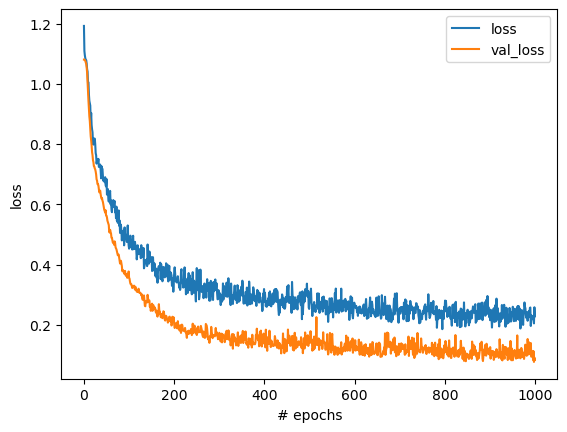

In [212]:
plt.plot(model.history.history['loss'],label='loss')
plt.plot(model.history.history['val_loss'],label='val_loss')
plt.legend()
plt.xlabel('# epochs')
plt.ylabel('loss')
plt.show()

In [214]:
model.save("plant_health_model.keras")
